In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
import shap
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,accuracy_score,recall_score
from imblearn.over_sampling import SMOTE
from sklearn.impute import KNNImputer
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')


c:\Users\LENOVO\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load The Dataset

In [2]:
data=pd.read_csv("processed_data.csv")
data.head()

,Unnamed: 0,Rating,Name,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,0,AA,Company 44,Rating agency 5,8/16/2005,Energy,0.885237,0.550896,0.143469,36.817520,0.094024,0.188131,1.009959,0.190213,0.143913,0.184689,0.160121,1.541119,3.390181,1.912761,0.631335,0.000000,0.547603,0.049198,10.433176,1.088336,0.190117,1.274560,3.093736,0.153534,0.000000
1,1,BB,Company 135,Rating agency 3,4/28/2009,Basic Industries,2.052828,0.511835,0.260385,0.000000,0.094189,0.132762,0.121490,0.137469,0.130518,0.223959,0.140879,1.388712,3.344361,2.253043,0.686885,0.284569,0.998442,6.286350,12.016261,3.298016,0.133657,0.959817,6.333349,0.032843,13.696790
2,2,CCC,Company 118,Rating agency 3,8/3/2010,Health Care,1.340032,1.090468,0.235971,45.137229,0.121169,0.017074,1.004473,0.069101,0.131112,0.023242,0.045285,1.093698,2.137543,3.829918,0.795181,0.309316,1.001744,0.965080,3.277277,4.811879,0.017046,15.625364,0.973799,0.051749,0.000000
3,4,BBB,Company 309,Rating agency 3,8/31/2010,Energy,1.393784,0.439914,0.027211,21.435616,0.199471,0.201420,0.990008,0.202475,0.083609,0.090809,0.211589,0.418874,0.487557,1.518487,0.606278,0.004395,-0.524239,-2.024697,4.779136,2.550233,0.200256,11.760623,3.911740,0.274350,0.000000
4,5,BBB,Company 56,Rating agency 3,9/30/2010,Miscellaneous,1.187288,0.514920,0.190278,53.102900,0.054140,0.097922,0.508211,0.099159,0.034475,0.089895,0.236613,0.639344,12.741720,1.384159,1.016996,0.386876,0.881115,4.040228,2.519301,2.403030,0.099138,10.459175,4.615069,0.176765,0.077434


Initial Data Overview

In [3]:
data = data.loc[:, ~data.columns.str.startswith('Unnamed')]

The rows with the Ratings: 'Lowest Risk and 'In Default are dropped from the dataset given their small value counts.

In [4]:
data = data[data['Rating']!='D']

In [5]:
data.describe()

,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,returnOnEquity,assetTurnover,fixedAssetTurnover,debtEquityRatio,debtRatio,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
count,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000,2028.000000
mean,1.590684,1.008271,0.366539,39.999932,0.071629,0.088649,0.512629,0.116918,0.047723,0.078707,0.141540,0.756283,4.767087,1.828538,0.644554,0.267485,0.556246,2.267185,4.431949,2.826562,0.093110,9.309509,4.552681,0.151698,5.898244
std,0.715848,0.548982,0.301224,24.957857,0.064851,0.079720,0.332808,0.089690,0.042640,0.075461,0.080061,0.474920,4.257637,0.954883,0.155143,0.152237,0.382759,2.645103,3.086093,0.920234,0.082356,4.580184,3.149925,0.106181,4.701389
min,-0.561963,-0.605174,-0.193124,0.000000,-0.119796,-0.152495,-0.583605,-0.151139,-0.068008,-0.132996,-0.000046,-0.058478,-0.023782,-1.005147,0.240851,-0.182093,-0.580118,-5.343165,-6.793396,-0.098755,-0.153577,-3.642940,-4.861714,-0.168286,-5.585685
25%,1.070339,0.596769,0.130620,22.628741,0.028892,0.034989,0.235472,0.053771,0.021856,0.031082,0.086805,0.384624,1.001247,1.133766,0.537334,0.184317,0.355317,0.496947,2.372066,2.151377,0.036936,6.261601,2.276416,0.075239,2.105584
50%,1.474983,0.946941,0.286238,40.864974,0.067792,0.087051,0.415903,0.112217,0.045788,0.072537,0.128641,0.672184,3.649595,1.642813,0.637759,0.292428,0.653776,2.015382,3.849005,2.662850,0.090718,9.068781,4.069670,0.130534,5.422505
75%,1.981179,1.323018,0.537513,56.083412,0.108540,0.136268,0.852101,0.168163,0.073540,0.128267,0.185135,1.026811,7.485155,2.327646,0.739774,0.360690,0.832322,3.810566,5.761219,3.323924,0.140354,12.020713,6.402676,0.214363,8.612972
max,3.807490,2.706340,1.370136,113.150210,0.253183,0.323086,1.735232,0.374182,0.164524,0.292448,0.418348,2.167586,19.759661,5.021523,1.070781,0.703125,1.655290,9.966066,17.743185,5.960783,0.331459,22.983333,14.785505,0.491876,20.193160


In [6]:
print("shape",data.shape)
print("\nColumn Type")
print(data.dtypes)


shape (2028, 30)

Column Type
Rating                                 object
Name                                   object
Rating Agency Name                     object
Date                                   object
Sector                                 object
currentRatio                          float64
quickRatio                            float64
cashRatio                             float64
daysOfSalesOutstanding                float64
netProfitMargin                       float64
pretaxProfitMargin                    float64
grossProfitMargin                     float64
operatingProfitMargin                 float64
returnOnAssets                        float64
returnOnCapitalEmployed               float64
returnOnEquity                        float64
assetTurnover                         float64
fixedAssetTurnover                    float64
debtEquityRatio                       float64
debtRatio                             float64
effectiveTaxRate                      float64
free

The rating dataset has 2434 rows and 30 columns

Categorical Encoding

- secotor --> Nominal(No order)
- Rating --> Ordinal

We are predicting the exact rating for a company

In [7]:
data.columns

Index(['Rating', 'Name', 'Rating Agency Name', 'Date', 'Sector',
       'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin',
       'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed',
       'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover',
       'debtEquityRatio', 'debtRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare',
       'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue',
       'enterpriseValueMultiple', 'operatingCashFlowPerShare',
       'operatingCashFlowSalesRatio', 'payablesTurnover'],
      dtype='object')

In [8]:
rating_class_dict = {
    'AAA': 'Investment Grade',
    'AA': 'Investment Grade',
    'A': 'Investment Grade',
    'BBB': 'Medium Grade',
    'BB': 'Speculative',
    'B': 'Speculative',
    'CCC': 'Highly Speculative',
    'CC': 'Highly Speculative',
    'C': 'Highly Speculative',
}
data['Rating_new'] = data['Rating'].map(rating_class_dict)

# Define explicit order
risk_order = [['Investment Grade', 'Medium Grade', 'Speculative','Highly Speculative']]

# Encode
encoder = OrdinalEncoder(categories=risk_order)
data['Rating_new'] = encoder.fit_transform(data[['Rating_new']])

In [9]:
data['Rating_new'].value_counts()

Rating_new
2.0    792
1.0    671
0.0    494
3.0     71
Name: count, dtype: int64

In [10]:
# Frequency encode Sector
sector_freq = data['Sector'].value_counts(normalize=True)
data['Sector'] = data['Sector'].map(sector_freq)

In [11]:
# Features and targets
X = data.drop(columns=['Rating', 'Rating Agency Name', 'Name', 'Date', 'Rating_new'])
y_grouped = data['Rating_new']

Tran_test_split

In [12]:
# Train/test split
X_train, X_test, y_train_grouped, y_test_grouped = train_test_split(
    X, y_grouped, test_size=0.2, random_state=42
)

# Scale
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
models={
    'Logistocs Regression':LogisticRegression(max_iter=1000,random_state=42),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier':RandomForestClassifier(class_weight='balanced',random_state=42),
    'XGboost':XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    
}

#fir and evaluate 

for name,model in models.items():
    model.fit(X_train_scaled,y_train_grouped)
    y_pred=model.predict(X_test_scaled)

    print(f"\n Model: {name}")
    print(classification_report(y_test_grouped,y_pred))


 Model: Logistocs Regression
              precision    recall  f1-score   support

         0.0       0.44      0.38      0.41        94
         1.0       0.42      0.41      0.41       131
         2.0       0.63      0.73      0.67       168
         3.0       0.00      0.00      0.00        13

    accuracy                           0.52       406
   macro avg       0.37      0.38      0.37       406
weighted avg       0.50      0.52      0.51       406


 Model: Decision Tree
              precision    recall  f1-score   support

         0.0       0.46      0.50      0.48        94
         1.0       0.47      0.49      0.48       131
         2.0       0.63      0.54      0.58       168
         3.0       0.17      0.31      0.22        13

    accuracy                           0.51       406
   macro avg       0.43      0.46      0.44       406
weighted avg       0.52      0.51      0.51       406


 Model: Random Forest Classifier
              precision    recall  f1-score

In [14]:
# Class label mapping for Stage 2
label_map = {
    '0.0': 'Investment Grade',
    '1.0': 'Medium Grade',
    '2.0': 'Speculative',
    '3.0': 'Highly Speculative'
}

# Class labels to extract from report
class_labels = list(label_map.keys())

# Create dictionaries to collect precision and recall
precision_scores = {}
recall_scores = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train_grouped)
    y_pred = model.predict(X_test_scaled)
    
    # Classification report as dictionary
    report = classification_report(y_test_grouped, y_pred, output_dict=True, zero_division=0)
    
    # Extract precision and recall for each class
    precision = [report[label]['precision'] if label in report else 0 for label in class_labels]
    recall = [report[label]['recall'] if label in report else 0 for label in class_labels]
    
    precision_scores[name] = precision
    recall_scores[name] = recall

# Convert to DataFrames
precision_df = pd.DataFrame.from_dict(precision_scores, orient='index', columns=[label_map[l] for l in class_labels])
recall_df = pd.DataFrame.from_dict(recall_scores, orient='index', columns=[label_map[l] for l in class_labels])

In [15]:
print("Report keys:", report.keys())


Report keys: dict_keys(['0.0', '1.0', '2.0', '3.0', 'accuracy', 'macro avg', 'weighted avg'])


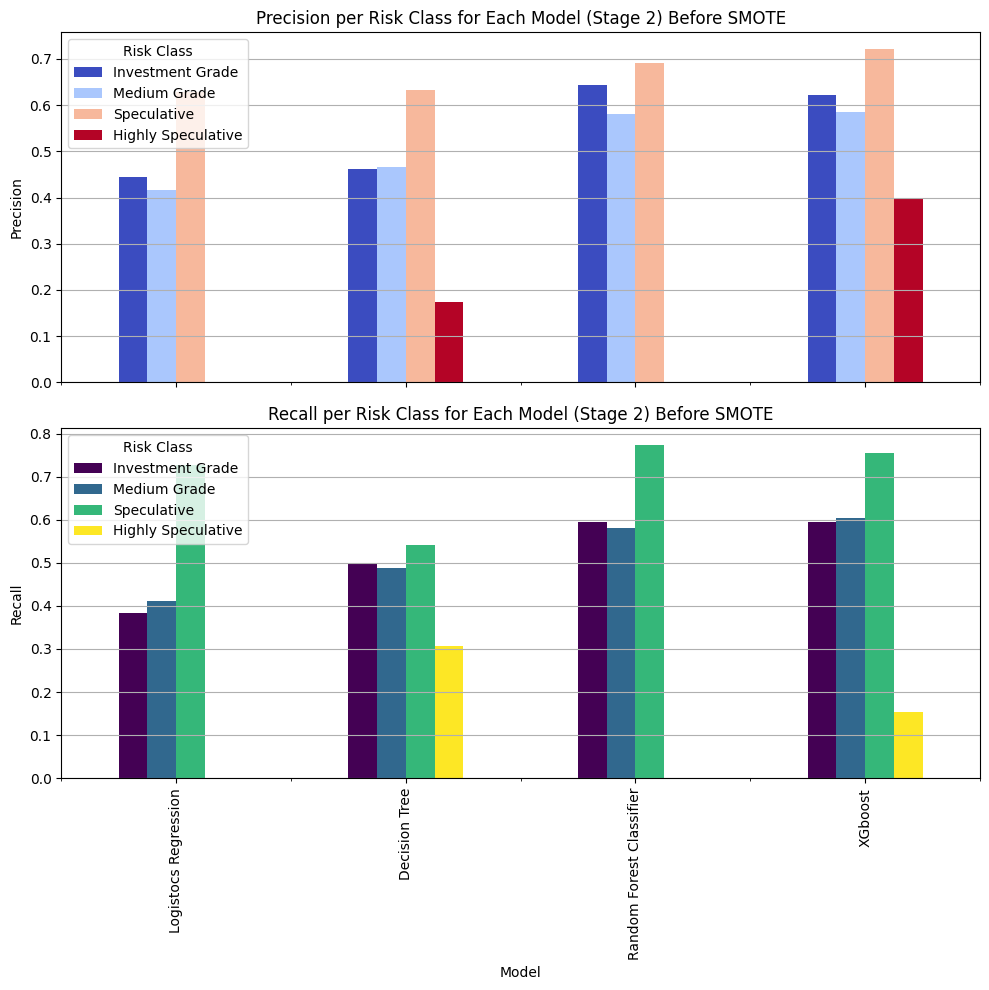

In [16]:
# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Precision chart
precision_df.plot(kind='bar', ax=axs[0], colormap='coolwarm')
axs[0].set_title('Precision per Risk Class for Each Model (Stage 2) Before SMOTE')
axs[0].set_ylabel('Precision')
axs[0].legend(title='Risk Class')
axs[0].grid(axis='y')

# Recall chart
recall_df.plot(kind='bar', ax=axs[1], colormap='viridis')
axs[1].set_title('Recall per Risk Class for Each Model (Stage 2) Before SMOTE')
axs[1].set_ylabel('Recall')
axs[1].set_xlabel('Model')
axs[1].legend(title='Risk Class')
axs[1].grid(axis='y')

plt.tight_layout()
plt.show()

In [17]:
y_train_grouped.value_counts()

Rating_new
2.0    624
1.0    540
0.0    400
3.0     58
Name: count, dtype: int64

In [18]:
# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_grouped)

# # Check new class balance
# pd.Series(y_train_resampled).value_counts()

# Only oversample class 3.0 up to, say, 300 samples (tunable)
smote = SMOTE(sampling_strategy={3.0: 400}, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_grouped)

# Check new distribution
pd.Series(y_train_resampled).value_counts()


Rating_new
2.0    624
1.0    540
3.0    400
0.0    400
Name: count, dtype: int64

In [19]:
models={
    'Logistocs Regression':LogisticRegression(max_iter=1000,random_state=42),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest Classifier':RandomForestClassifier(class_weight='balanced',random_state=42),
    'XGboost':XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    
}

#fir and evaluate 

for name,model in models.items():
    model.fit(X_train_resampled,y_train_resampled)
    y_pred=model.predict(X_test_scaled)

    print(f"\n Model: {name}")
    print(classification_report(y_test_grouped,y_pred))


 Model: Logistocs Regression
              precision    recall  f1-score   support

         0.0       0.48      0.43      0.45        94
         1.0       0.43      0.42      0.43       131
         2.0       0.60      0.55      0.57       168
         3.0       0.14      0.46      0.21        13

    accuracy                           0.48       406
   macro avg       0.41      0.46      0.42       406
weighted avg       0.50      0.48      0.49       406


 Model: Decision Tree
              precision    recall  f1-score   support

         0.0       0.46      0.47      0.47        94
         1.0       0.44      0.45      0.45       131
         2.0       0.59      0.49      0.53       168
         3.0       0.18      0.54      0.27        13

    accuracy                           0.47       406
   macro avg       0.42      0.49      0.43       406
weighted avg       0.50      0.47      0.48       406


 Model: Random Forest Classifier
              precision    recall  f1-score

In [20]:
# Class label mapping for Stage 2
label_map = {
    '0.0': 'Investment Grade',
    '1.0': 'Medium Grade',
    '2.0': 'Speculative',
    '3.0': 'Highly Speculative'
}

# Class labels to extract from report
class_labels = list(label_map.keys())

# Create dictionaries to collect precision and recall
precision_scores = {}
recall_scores = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
    
    # Classification report as dictionary
    report = classification_report(y_test_grouped, y_pred, output_dict=True, zero_division=0)
    
    # Extract precision and recall for each class
    precision = [report[label]['precision'] if label in report else 0 for label in class_labels]
    recall = [report[label]['recall'] if label in report else 0 for label in class_labels]
    
    precision_scores[name] = precision
    recall_scores[name] = recall

# Convert to DataFrames
precision_df = pd.DataFrame.from_dict(precision_scores, orient='index', columns=[label_map[l] for l in class_labels])
recall_df = pd.DataFrame.from_dict(recall_scores, orient='index', columns=[label_map[l] for l in class_labels])

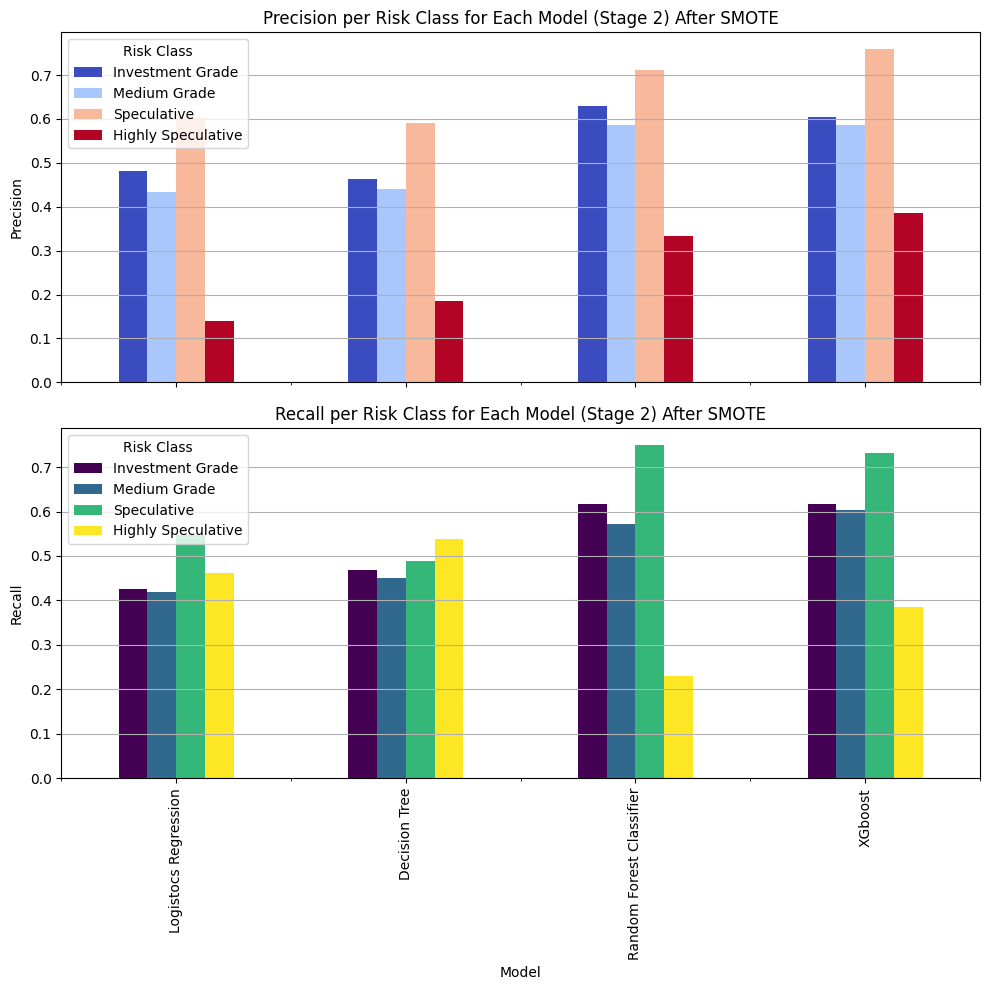

In [21]:
# Plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Precision chart
precision_df.plot(kind='bar', ax=axs[0], colormap='coolwarm')
axs[0].set_title('Precision per Risk Class for Each Model (Stage 2) After SMOTE')
axs[0].set_ylabel('Precision')
axs[0].legend(title='Risk Class')
axs[0].grid(axis='y')

# Recall chart
recall_df.plot(kind='bar', ax=axs[1], colormap='viridis')
axs[1].set_title('Recall per Risk Class for Each Model (Stage 2) After SMOTE')
axs[1].set_ylabel('Recall')
axs[1].set_xlabel('Model')
axs[1].legend(title='Risk Class')
axs[1].grid(axis='y')

plt.tight_layout()
plt.show()

Hyperparameter Tuning

In [22]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

# Set up GridSearch
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit
rf_grid_search.fit(X_train_resampled, y_train_resampled)

# Best model
best_rf = rf_grid_search.best_estimator_
print("Best Random Forest Params:", rf_grid_search.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Random Forest Params: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [23]:
#Best Random Forest Params:
{'class_weight': 'balanced',
  'max_depth':20,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 200
}

# Re-train using best parameters
best_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

best_rf_model.fit(X_train_resampled, y_train_resampled)

# Predict on test data
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)

# Evaluate
print("🎯 Tuned Random Forest Classifier Performance:")
print(classification_report(y_test_grouped, y_pred_rf_tuned))


🎯 Tuned Random Forest Classifier Performance:
              precision    recall  f1-score   support

         0.0       0.64      0.59      0.61        94
         1.0       0.59      0.58      0.58       131
         2.0       0.70      0.76      0.73       168
         3.0       0.33      0.23      0.27        13

    accuracy                           0.64       406
   macro avg       0.56      0.54      0.55       406
weighted avg       0.64      0.64      0.64       406



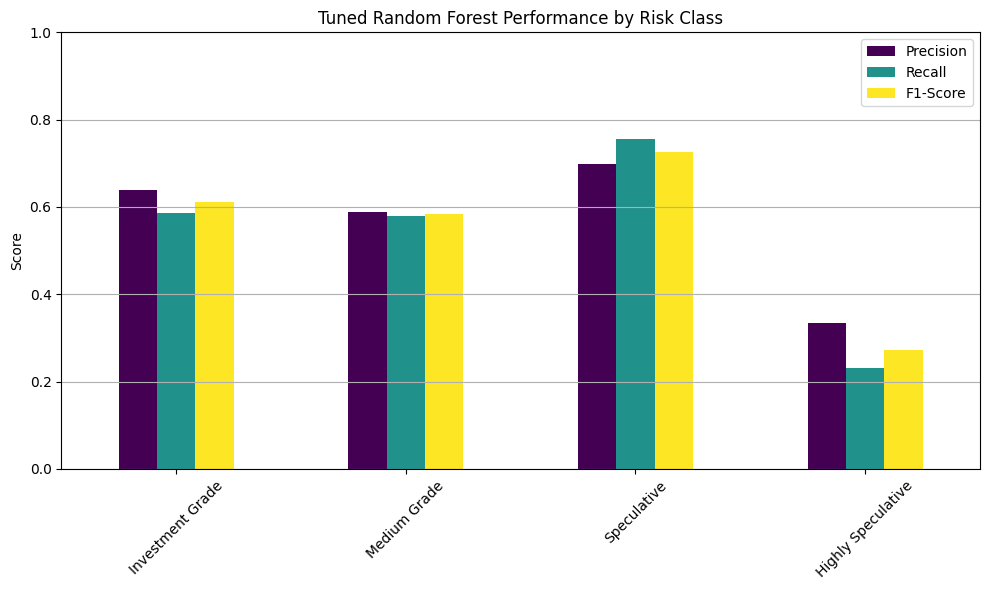

In [24]:
# Get classification report
report = classification_report(y_test_grouped, y_pred_rf_tuned, output_dict=True, zero_division=0)

# Define class label mapping
label_map = {
    '0.0': 'Investment Grade',
    '1.0': 'Medium Grade',
    '2.0': 'Speculative',
    '3.0': 'Highly Speculative'
}

# Extract metrics
class_labels = list(label_map.keys())

precision = [report[label]['precision'] for label in class_labels]
recall = [report[label]['recall'] for label in class_labels]
f1 = [report[label]['f1-score'] for label in class_labels]

# Create DataFrame
metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=[label_map[l] for l in class_labels])

# Plot
metrics_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Tuned Random Forest Performance by Risk Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7,10,20],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_resampled, y_train_resampled)

# Best model
best_xgb = xgb_grid_search.best_estimator_
print("Best XGBoost Params:", xgb_grid_search.best_params_)


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best XGBoost Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [26]:
{
  'colsample_bytree': 0.8,
  'learning_rate': 0.1,
  'max_depth': 7,
  'n_estimators': 200,
  'subsample': 0.8
}
# Retrain XGBoost with best parameters
best_xgb_model = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    subsample=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Fit on SMOTE-resampled data
best_xgb_model.fit(X_train_resampled, y_train_resampled)

# Predict on test set
y_pred_xgb_tuned = best_xgb_model.predict(X_test_scaled)

# Evaluate
print("🎯 Tuned XGBoost Classifier Performance:")
print(classification_report(y_test_grouped, y_pred_xgb_tuned))

🎯 Tuned XGBoost Classifier Performance:
              precision    recall  f1-score   support

         0.0       0.67      0.66      0.66        94
         1.0       0.60      0.61      0.60       131
         2.0       0.75      0.76      0.75       168
         3.0       0.56      0.38      0.45        13

    accuracy                           0.67       406
   macro avg       0.64      0.60      0.62       406
weighted avg       0.67      0.67      0.67       406



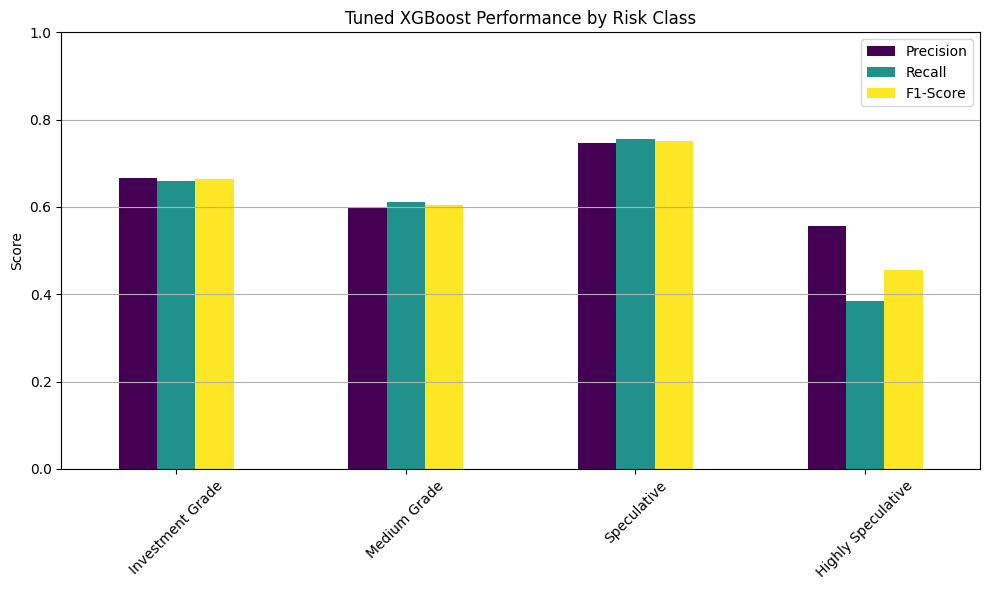

In [27]:
# Get classification report
report = classification_report(y_test_grouped, y_pred_xgb_tuned, output_dict=True, zero_division=0)

# Define class label mapping
label_map = {
    '0.0': 'Investment Grade',
    '1.0': 'Medium Grade',
    '2.0': 'Speculative',
    '3.0': 'Highly Speculative'
}

# Extract metrics
class_labels = list(label_map.keys())

precision = [report[label]['precision'] for label in class_labels]
recall = [report[label]['recall'] for label in class_labels]
f1 = [report[label]['f1-score'] for label in class_labels]

# Create DataFrame
metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=[label_map[l] for l in class_labels])

# Plot
metrics_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title("Tuned XGBoost Performance by Risk Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Feature Importance

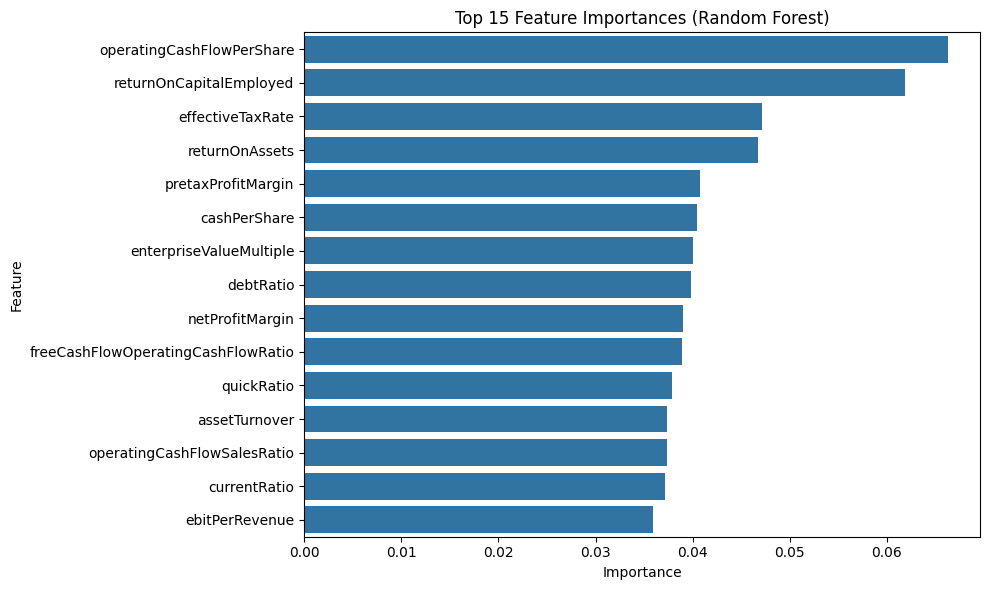

In [28]:
# Assuming you have a trained RandomForest model and X (feature DataFrame)
feature_importances = best_rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

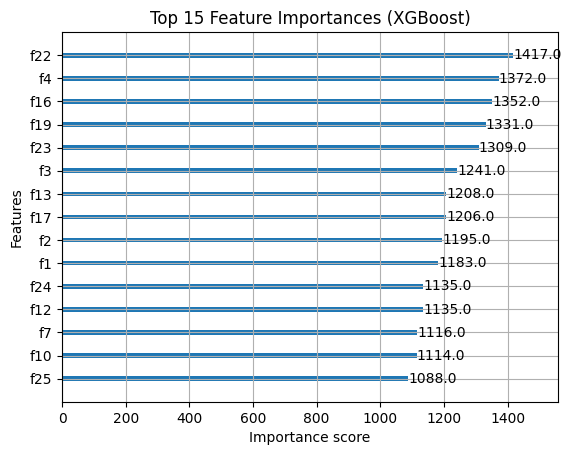

In [29]:
# Plot feature importances from XGBoost
import xgboost as xgb
xgb.plot_importance(best_xgb_model, max_num_features=15, importance_type='weight', title='Top 15 Feature Importances (XGBoost)')
plt.show()

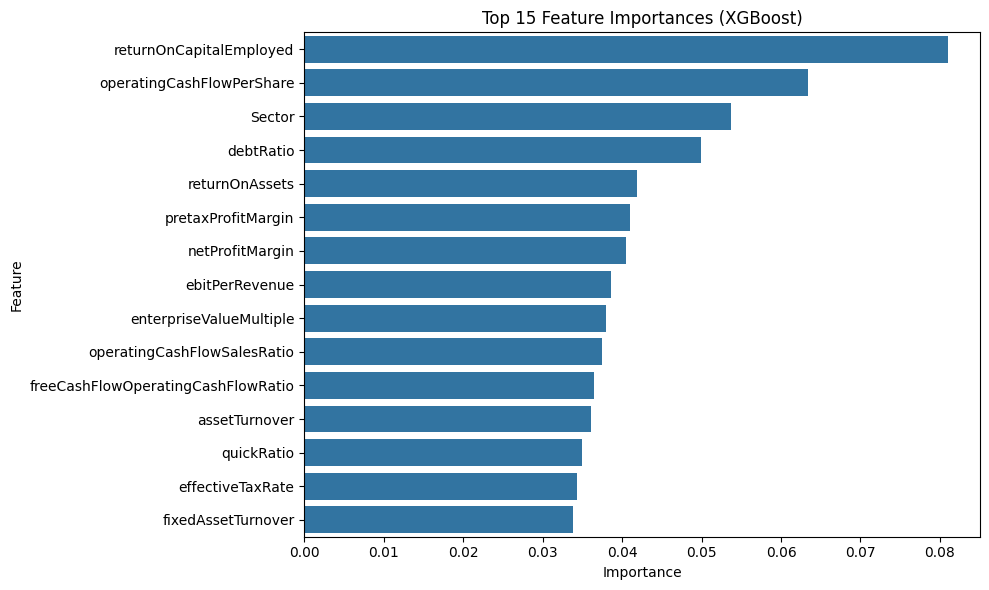

In [30]:
# Assuming you have a trained RandomForest model and X (feature DataFrame)
feature_importances = best_xgb_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()

In [31]:
import category_encoders as ce
from sklearn.model_selection import StratifiedKFold
from category_encoders import TargetEncoder

# Features and targets
X = data.drop(columns=['Rating', 'Rating Agency Name', 'Name', 'Date', 'Rating_new'])
y_grouped = data['Rating_new']

# 2. Target encoding for 'Sector'
te = TargetEncoder()
X['Sector'] = te.fit_transform(X['Sector'], y_grouped)

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_grouped, test_size=0.2, random_state=42, stratify=y_grouped)

# 4. Scaling using RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Apply SMOTE to class 3 only
smote = SMOTE(sampling_strategy={3.0: 400}, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 6. Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_scaled)

print("🎯 Random Forest Performance (After Target Encoding + Scaling + SMOTE):")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# 7. Train XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    use_label_encoder=False,
    random_state=42
)
xgb_model.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("🎯 XGBoost Performance (After Target Encoding + Scaling + SMOTE):")
print(classification_report(y_test, y_pred_xgb, zero_division=0))








🎯 Random Forest Performance (After Target Encoding + Scaling + SMOTE):
              precision    recall  f1-score   support

         0.0       0.80      0.60      0.68        99
         1.0       0.63      0.67      0.65       134
         2.0       0.71      0.79      0.75       159
         3.0       0.36      0.29      0.32        14

    accuracy                           0.69       406
   macro avg       0.62      0.59      0.60       406
weighted avg       0.69      0.69      0.68       406

🎯 XGBoost Performance (After Target Encoding + Scaling + SMOTE):
              precision    recall  f1-score   support

         0.0       0.75      0.67      0.71        99
         1.0       0.67      0.65      0.66       134
         2.0       0.74      0.84      0.79       159
         3.0       0.40      0.29      0.33        14

    accuracy                           0.71       406
   macro avg       0.64      0.61      0.62       406
weighted avg       0.71      0.71      0.71      

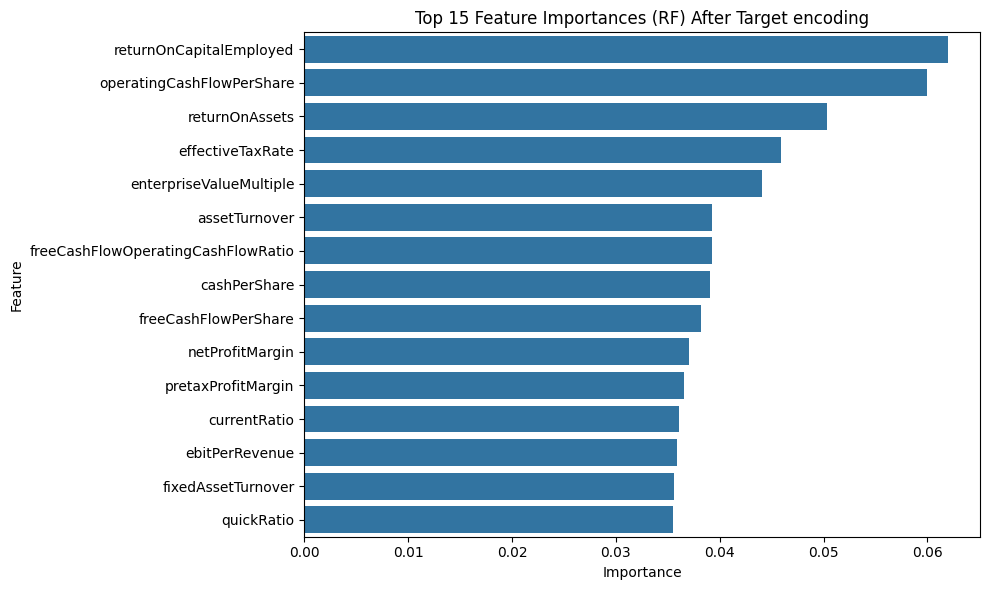

In [32]:
# Assuming you have a trained RandomForest model and X (feature DataFrame)
feature_importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Feature Importances (RF) After Target encoding")
plt.tight_layout()
plt.show()

In [35]:
# Initialize SHAP explainer
explainer = shap.Explainer(best_xgb_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Get average absolute SHAP values
mean_shap = np.abs(shap_values.values).mean(axis=0)
print(mean_shap)
# shap_summary = pd.DataFrame({
#     "Feature": X.columns,
#     "Mean |SHAP|": mean_shap
# }).sort_values(by="Mean |SHAP|", ascending=False)

# # Show top features
# print(shap_summary.head(10))

 99%|===================| 1606/1624 [01:16<00:00]        

[[0.17074644 0.06866623 0.33832237 0.20471402]
 [0.11167554 0.1320531  0.24674238 0.12575313]
 [0.17795163 0.0646665  0.17636869 0.20433298]
 [0.12715867 0.07059092 0.08344524 0.08444796]
 [0.08528341 0.09497955 0.09420529 0.21675561]
 [0.19422216 0.17647231 0.1420739  0.10920439]
 [0.19195972 0.09850034 0.07705933 0.11641961]
 [0.15899882 0.1448121  0.07431256 0.06009878]
 [0.05360536 0.12776124 0.08827707 0.07458615]
 [0.22978449 0.26400807 0.19056606 0.09584808]
 [0.39394342 0.13182814 0.13279498 0.21380286]
 [0.09071906 0.08315079 0.21056927 0.06749256]
 [0.19050891 0.11745093 0.17958879 0.05877117]
 [0.18503217 0.08976908 0.1794654  0.16333897]
 [0.04758799 0.07351668 0.07903861 0.13324945]
 [0.20524267 0.27847389 0.19494632 0.38860044]
 [0.11209102 0.14669982 0.16168383 0.27549236]
 [0.14337638 0.20561094 0.11524137 0.23332941]
 [0.18723811 0.07402669 0.05308248 0.03887906]
 [0.1158654  0.11484214 0.216621   0.14801425]
 [0.09751888 0.07085171 0.08427524 0.04189469]
 [0.13850533 

In [36]:
# Average SHAP values for class 3 (e.g., Highly Speculative)
shap_class_3 = shap_values.values[:, :, 3]  # Shape: (num_samples, num_features)

# Compute mean absolute SHAP value per feature
mean_shap_class_3 = np.abs(shap_class_3).mean(axis=0)

# Build DataFrame
shap_summary = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP| (Class 3)": mean_shap_class_3
}).sort_values(by="Mean |SHAP| (Class 3)", ascending=False)

print(shap_summary.head(10))

                               Feature  Mean |SHAP| (Class 3)
23           operatingCashFlowPerShare               0.645963
15                           debtRatio               0.388600
16                    effectiveTaxRate               0.275492
17  freeCashFlowOperatingCashFlowRatio               0.233329
4               daysOfSalesOutstanding               0.216756
10             returnOnCapitalEmployed               0.213803
24         operatingCashFlowSalesRatio               0.212339
0                               Sector               0.204714
2                           quickRatio               0.204333
25                    payablesTurnover               0.178766


In [39]:
# Initialize SHAP explainer
explainer_rf = shap.Explainer(best_rf_model, X_train_scaled)
shap_values_rf = explainer_rf(X_test_scaled)

# Get average absolute SHAP values
mean_shap_rf = np.abs(shap_values_rf.values).mean(axis=0)


# Average SHAP values for class 3 (e.g., Highly Speculative)
shap_class_3 = shap_values.values[:, :, 3]  # Shape: (num_samples, num_features)

# Compute mean absolute SHAP value per feature
mean_shap_class_3 = np.abs(shap_class_3).mean(axis=0)

# Build DataFrame
shap_summary = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP| (Class 3)": mean_shap_class_3
}).sort_values(by="Mean |SHAP| (Class 3)", ascending=False)

print(shap_summary.head(10))

100%|===================| 1616/1624 [01:50<00:00]        

                               Feature  Mean |SHAP| (Class 3)
23           operatingCashFlowPerShare               0.023236
15                           debtRatio               0.013857
16                    effectiveTaxRate               0.013498
10             returnOnCapitalEmployed               0.012939
19                        cashPerShare               0.007748
9                       returnOnAssets               0.007579
17  freeCashFlowOperatingCashFlowRatio               0.007531
6                   pretaxProfitMargin               0.007442
24         operatingCashFlowSalesRatio               0.006479
5                      netProfitMargin               0.006336


In [ ]:
# Average SHAP values for class 3 (e.g., Highly Speculative)
shap_class_3 = shap_values.values[:, :, 3]  # Shape: (num_samples, num_features)

# Compute mean absolute SHAP value per feature
mean_shap_class_3 = np.abs(shap_class_3).mean(axis=0)

# Build DataFrame
shap_summary = pd.DataFrame({
    "Feature": X.columns,
    "Mean |SHAP| (Class 3)": mean_shap_class_3
}).sort_values(by="Mean |SHAP| (Class 3)", ascending=False)

print(shap_summary.head(10))